# 01 — Preprocessing
Load the raw Online Retail dataset, perform some preprocessing, and save the processed dataset.

In [ ]:
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent
RAW_DATA = PROJECT_ROOT / "data" / "raw" / "Online Retail.xlsx"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# Load raw data
raw = pd.read_excel(RAW_DATA, dtype={"CustomerID": str})
print(f"Loaded {len(raw):,} rows")

In [3]:
# Testing for invalid data cases
print("Shape:", raw.shape)
print("\nDtypes:")
print(raw.dtypes)
print("\nMissing value counts:")
print(raw.isnull().sum())
print("\nSample rows:")
raw.head()

Shape: (541909, 8)

Dtypes:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
dtype: object

Missing value counts:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Sample rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [ ]:
# Apply cleaning
df = raw.copy()

# Remove cancelled invoices (InvoiceNo starting with 'C')
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove non-positive quantities and prices
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Strip whitespace from Description
df["Description"] = df["Description"].astype(str).str.strip()

# Add TotalPrice
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df = df.reset_index(drop=True)

print(f"Before cleaning : {len(raw):,} rows")
print(f"After cleaning  : {len(df):,} rows")
print(f"Rows removed    : {len(raw) - len(df):,} ({(len(raw) - len(df)) / len(raw) * 100:.1f}%)")

In [5]:
# Show some statistics about the data
print("Date range:")
print(f"  {df['InvoiceDate'].min()}  →  {df['InvoiceDate'].max()}")
print(f"\nUnique customers : {df['CustomerID'].nunique():,}")
print(f"Unique products  : {df['StockCode'].nunique():,}")
print(f"Unique invoices  : {df['InvoiceNo'].nunique():,}")
print("\nTop 10 countries by transaction count:")
print(df['Country'].value_counts().head(10))

Date range:
  2010-12-01 08:26:00  →  2011-12-09 12:50:00

Unique customers : 4,338
Unique products  : 3,922
Unique invoices  : 19,960

Top 10 countries by transaction count:
Country
United Kingdom    485123
Germany             9040
France              8407
EIRE                7890
Spain               2484
Netherlands         2359
Belgium             2031
Switzerland         1966
Portugal            1501
Australia           1182
Name: count, dtype: int64


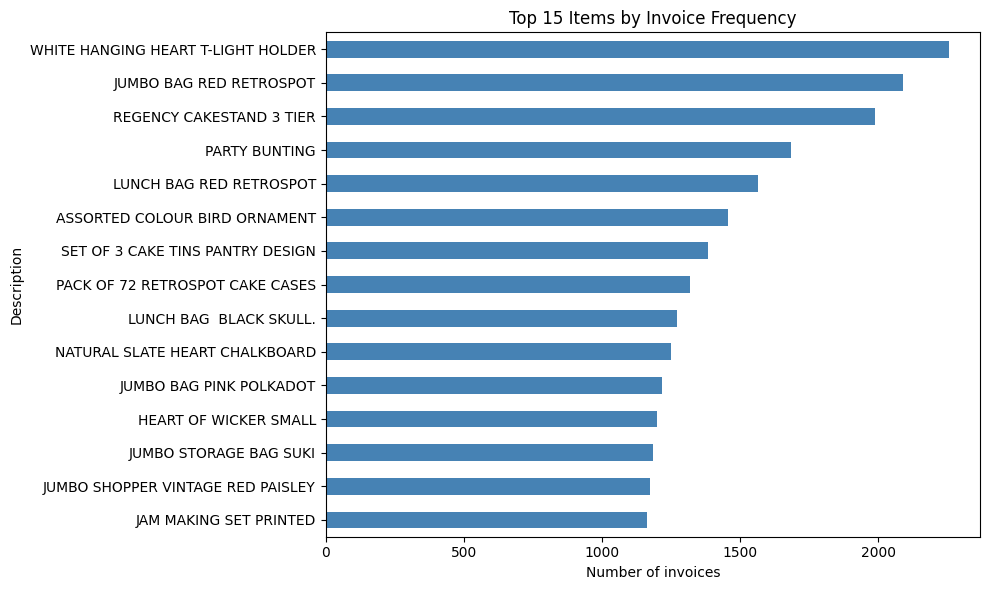

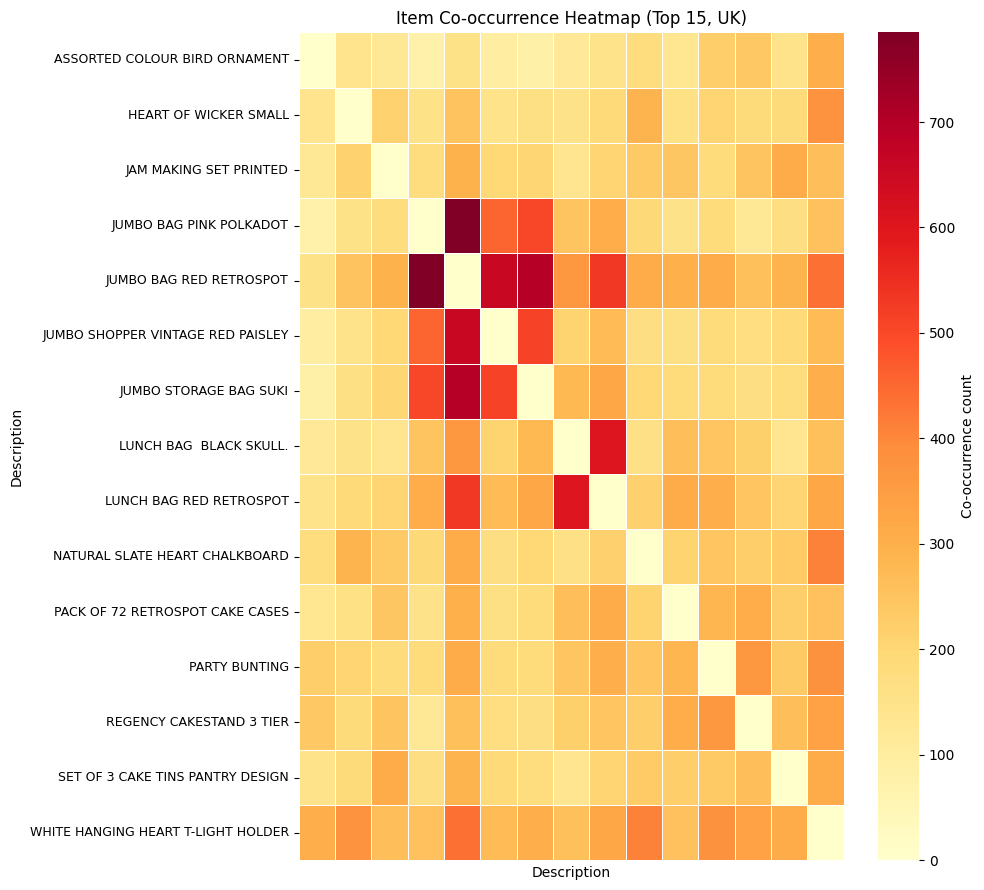

In [6]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

# Top 15 most frequently purchased items
top_items = (
    df.groupby("Description")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

# Bar chart of item frequency
fig, ax = plt.subplots(figsize=(10, 6))
top_items.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Number of invoices")
ax.set_title("Top 15 Items by Invoice Frequency")
plt.tight_layout()
plt.show()

# Co-occurrence heatmap for top 15 items
top_names = top_items.index.tolist()

uk_df = df[df["Country"] == "United Kingdom"]
basket = (
    uk_df[uk_df["Description"].isin(top_names)]
    .groupby(["InvoiceNo", "Description"])["Quantity"]
    .sum()
    .unstack(fill_value=0)
    .map(lambda x: 1 if x > 0 else 0)
)

cooc = basket.T.dot(basket)
for item in cooc.columns:
    cooc.loc[item, item] = 0

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(
    cooc,
    ax=ax,
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Co-occurrence count"},
    xticklabels=False,  # very hard to fit long labels on the bottom of the matrix
)
ax.set_title("Item Co-occurrence Heatmap (Top 15, UK)")
ax.tick_params(axis="y", rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

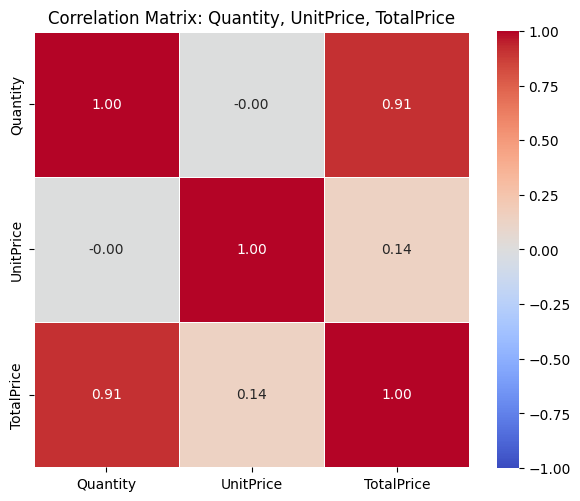

In [12]:
# Correlation matrix of numeric features
corr = df[["Quantity", "UnitPrice", "TotalPrice"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=ax,
    linewidths=0.5,
    square=True,
)
ax.set_title("Correlation Matrix: Quantity, UnitPrice, TotalPrice")
plt.tight_layout()
plt.show()

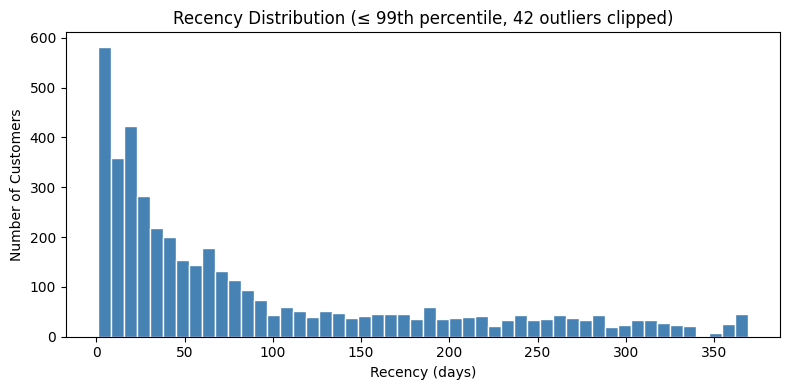

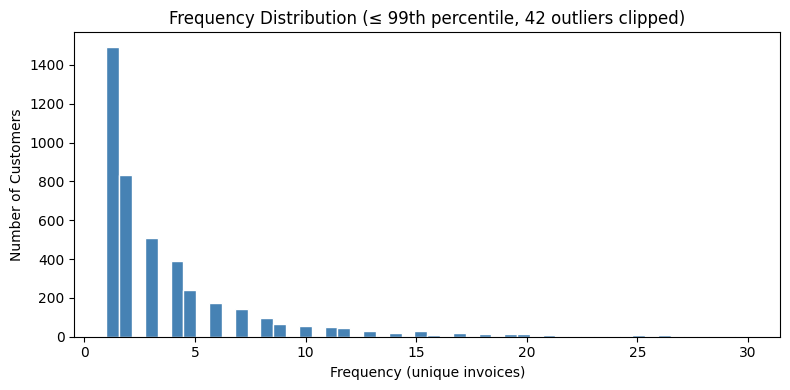

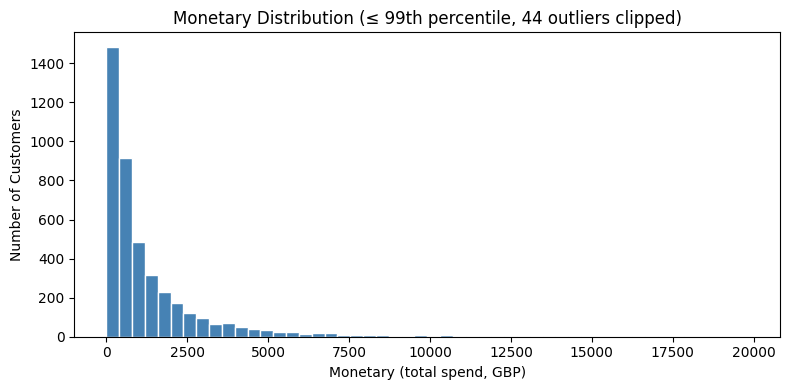

       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2054.27
std     100.01       7.70    8989.23
min       1.00       1.00       3.75
25%      18.00       1.00     307.41
50%      51.00       2.00     674.48
75%     142.00       5.00    1661.74
max     374.00     209.00  280206.02


In [13]:
# RFM distributions (preview for customer segmentation)
# Filter to rows with CustomerID for RFM
rfm_df = df.dropna(subset=["CustomerID"]).copy()
max_date = rfm_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    rfm_df.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (max_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalPrice", "sum"),
    )
)

for col, xlabel in [
    ("Recency", "Recency (days)"),
    ("Frequency", "Frequency (unique invoices)"),
    ("Monetary", "Monetary (total spend, GBP)"),
]:
    p99 = rfm[col].quantile(0.99)
    clipped = rfm[col][rfm[col] <= p99]
    n_outliers = len(rfm) - len(clipped)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(clipped, bins=50, color="steelblue", edgecolor="white")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of Customers")
    ax.set_title(f"{col} Distribution (≤ 99th percentile, {n_outliers} outliers clipped)")
    plt.tight_layout()
    plt.show()

print(rfm.describe().round(2))

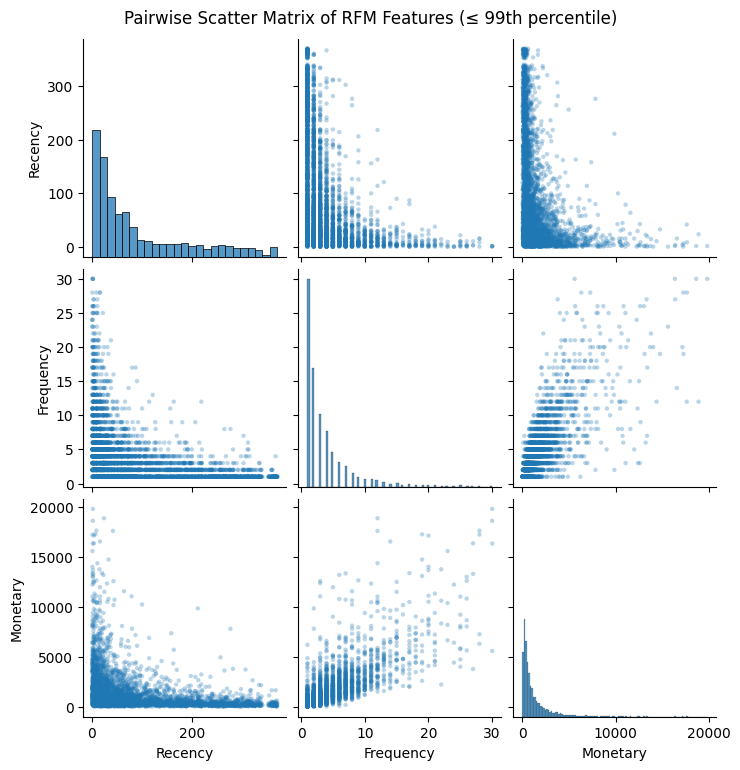

In [15]:
# RFM pairwise scatter matrix
rfm_clipped = rfm[
    (rfm["Recency"] <= rfm["Recency"].quantile(0.99))
    & (rfm["Frequency"] <= rfm["Frequency"].quantile(0.99))
    & (rfm["Monetary"] <= rfm["Monetary"].quantile(0.99))
]

sns.pairplot(rfm_clipped[["Recency", "Frequency", "Monetary"]], diag_kind="hist", plot_kws={"alpha": 0.3, "s": 10, "edgecolor": "none"})
plt.suptitle("Pairwise Scatter Matrix of RFM Features (≤ 99th percentile)", y=1.02)
plt.show()

In [ ]:
# --- Daily sales by product category (preview for time series analysis) ---
import re

# Categories derived from the top-selling product descriptions
CATEGORIES = {
    "Lunch":            r"LUNCH",
    "Hot Water Bottle":  r"HOT WATER BOTTLE",
    "Night Light":      r"NIGHT LIGHT",
    "Alarm Clock":      r"ALARM CLOCK",
    "Christmas":        r"CHRISTMAS|XMAS|NOEL",
    "Retrospot":        r"RETROSPOT",
    "T-Light":          r"T-LIGHT|TLIGHT|TEA LIGHT|CANDLE",
    "Heart":            r"HEART",
    "Baking":           r"CAKE|BAKING|COOKIE|MOULD",
    "Bunting":          r"BUNTING",
    "Sign":             r"SIGN",
    "Frame":            r"FRAME",
    "Doormat":          r"DOORMAT",
    "Jam":              r"JAM MAKING|JAM SET",
    "Bag":              r"BAG|SHOPPER",
}

def assign_category(desc):
    desc_upper = str(desc).upper()
    for cat, pattern in CATEGORIES.items():
        if re.search(pattern, desc_upper):
            return cat
    return None

df["Category"] = df["Description"].apply(assign_category)

cat_counts = df["Category"].value_counts()
print(f"Rows assigned to a category: {df['Category'].notna().sum():,} "
      f"({df['Category'].notna().mean()*100:.1f}%)")
print(f"\nCategory counts:")
print(cat_counts)

# Daily sales for selected categories
cat_df = df.dropna(subset=["Category"]).copy()
cat_df["Date"] = cat_df["InvoiceDate"].dt.date
daily = cat_df.groupby(["Date", "Category"])["TotalPrice"].sum().reset_index()
daily_pivot = daily.pivot_table(index="Date", columns="Category", values="TotalPrice", fill_value=0)
daily_pivot.index = pd.to_datetime(daily_pivot.index)

fig, ax = plt.subplots(figsize=(12, 5))
for cat in ["Christmas", "Heart", "T-Light", "Bag"]:
    if cat in daily_pivot.columns:
        ax.plot(daily_pivot.index, daily_pivot[cat], label=cat, alpha=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("Daily Sales (GBP)")
ax.set_title("Daily Sales for Selected Categories")
ax.legend()
plt.tight_layout()
plt.show()

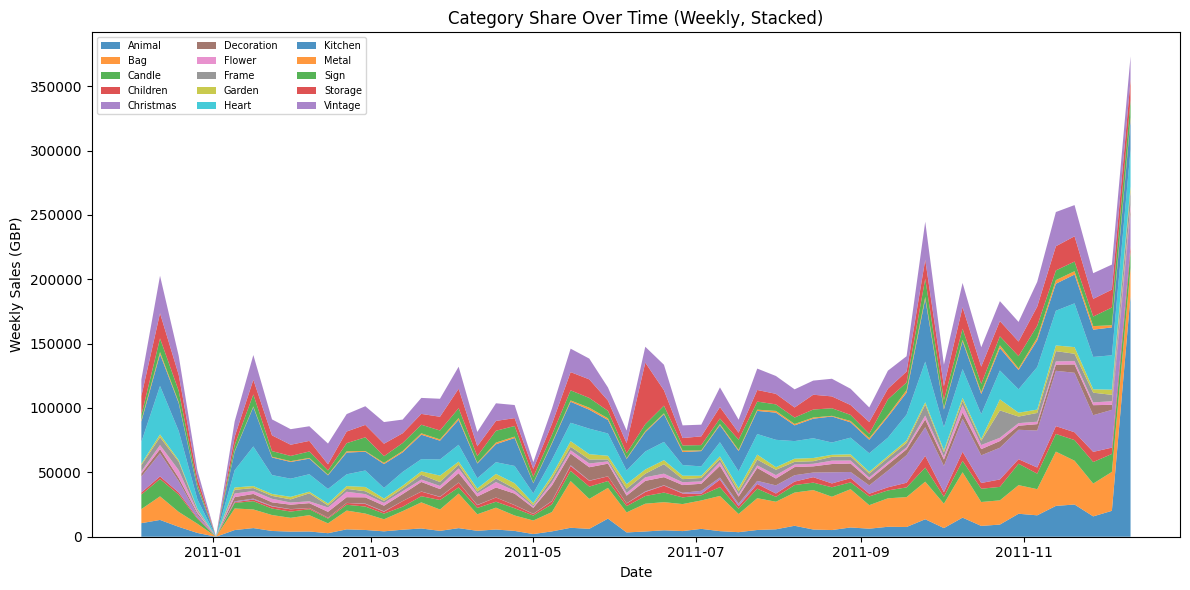

In [17]:
# Category volume comparison: stacked area chart
# Resample to weekly to smooth out daily noise
weekly = daily_pivot.resample("W").sum()

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(
    weekly.index,
    [weekly[cat] for cat in weekly.columns],
    labels=weekly.columns,
    alpha=0.8,
)
ax.set_xlabel("Date")
ax.set_ylabel("Weekly Sales (GBP)")
ax.set_title("Category Share Over Time (Weekly, Stacked)")
ax.legend(loc="upper left", fontsize=7, ncol=3)
plt.tight_layout()
plt.show()

In [18]:
# Save processed data as a CSV file
out_path = PROCESSED_DIR / "online_retail_clean.csv"
df.to_csv(out_path, index=False)
print(f"Saved {len(df):,} rows → {out_path}")

Saved 530,104 rows → c:\Users\powell\Documents\Datamining Project\CS4412-Online-Retail-Datamining\data\processed\online_retail_clean.csv
